In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, f_oneway
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

task 1


In [158]:
#1.1 loading dataset
df=pd.read_csv('G3.csv')
df.head()


,enterprise_group_id,display_name,enterprise_group_name,group_root_lei,enterprise_group_jurisdiction,enterprise_group_entity_status,website,company_type,employees,employees_year,...,market_cap_date,legal_units_count,direct_subsidiaries_count,max_hierarchy_depth,is_standalone_entity,website_source,employees_source,revenue_source,net_income_source,market_cap_source
0,EG_03260722,Morgan Stanley,MORGAN STANLEY,IGJSJL3JD5P30I6NJZ34,US-DE,ACTIVE,morganstanley.com,PUBLIC,83000.0,2025.0,...,2025-12-31,1013,173.0,8.0,False,morganstanley.com,sec.gov,sec.gov,sec.gov,finance.yahoo.com
1,EG_03256960,Bank of America,BANK OF AMERICA CORPORATION,9DJT3UXIJIZJI4WXO774,US-DE,ACTIVE,bankofamerica.com,PUBLIC,213000.0,2025.0,...,2025-12-31,761,155.0,5.0,False,bankofamerica.com,sec.gov,sec.gov,https://investor.bankofamerica.com/regulatory-...,macrotrends.net
2,EG_01804232,Citigroup,CITIGROUP INC.,6SHGI4ZSSLCXXQSBB395,US-DE,ACTIVE,citigroup.com,PUBLIC,226000.0,2025.0,...,2025-12-31,742,22.0,9.0,False,citigroup.com,sec.gov,tradingview.com,tradingview.com,uk.finance.yahoo.com
3,EG_02027196,Goldman Sachs,"THE GOLDMAN SACHS GROUP, INC.",784F5XWPLTWKTBV3E584,US-DE,ACTIVE,https://www.goldmansachs.com,PUBLIC,47400.0,2025.0,...,2025-12-31,568,190.0,7.0,False,goldmansachs.com,sec.gov,goldmansachs.com,goldmansachs.com,finance.yahoo.com
4,EG_03266820,Siemens,Siemens Aktiengesellschaft,W38RGI023J3WT1HWRP32,DE,ACTIVE,siemens.com,PUBLIC,318000.0,2025.0,...,2025-09-30,568,454.0,3.0,False,siemens.com,siemens.com,siemens.com,siemens.com,siemens.com


In [159]:
df.shape

(1755, 28)

In [160]:
#1.2 identifying numerical and categorical features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1755 entries, 0 to 1754
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   enterprise_group_id             1755 non-null   object 
 1   display_name                    1755 non-null   object 
 2   enterprise_group_name           1755 non-null   object 
 3   group_root_lei                  1755 non-null   object 
 4   enterprise_group_jurisdiction   1755 non-null   object 
 5   enterprise_group_entity_status  1755 non-null   object 
 6   website                         1716 non-null   object 
 7   company_type                    1753 non-null   object 
 8   employees                       1656 non-null   float64
 9   employees_year                  1655 non-null   float64
 10  revenue                         1654 non-null   float64
 11  revenue_currency                1654 non-null   object 
 12  revenue_year                    16

In [161]:
#1.3 check for missing values and duplicated records
print(f'null values \n {df.isnull().sum()}\n')
print(f'duplicated count \n {df.duplicated().sum()}')

null values 
 enterprise_group_id                 0
display_name                        0
enterprise_group_name               0
group_root_lei                      0
enterprise_group_jurisdiction       0
enterprise_group_entity_status      0
website                            39
company_type                        2
employees                          99
employees_year                    100
revenue                           101
revenue_currency                  101
revenue_year                      102
net_income                        156
net_income_currency               156
net_income_year                   156
market_cap                        531
market_cap_currency               528
market_cap_date                   531
legal_units_count                   0
direct_subsidiaries_count           8
max_hierarchy_depth                 8
is_standalone_entity                0
website_source                     35
employees_source                   91
revenue_source                     8

In [162]:
#1.4 to generate summary statistics and visualize the distribution of revenue
df.describe()

,employees,employees_year,revenue,revenue_year,net_income,net_income_year,market_cap,legal_units_count,direct_subsidiaries_count,max_hierarchy_depth
count,1.656000e+03,1655.000000,1.654000e+03,1653.000000,1.599000e+03,1599.000000,1.224000e+03,1755.000000,1747.000000,1747.000000
mean,3.989013e+04,2024.951057,9.050901e+11,2024.923775,7.895350e+10,2024.914321,2.057347e+12,34.330484,17.531196,2.038351
std,9.625128e+04,0.312028,1.080451e+13,0.441763,1.216758e+12,0.459405,4.925187e+13,58.980527,27.903769,1.044385
min,0.000000e+00,2023.000000,-3.518000e+09,2012.000000,-1.060000e+12,2012.000000,8.270000e+06,1.000000,0.000000,0.000000
25%,2.521750e+03,2025.000000,2.198500e+09,2025.000000,5.681000e+07,2025.000000,3.600000e+09,11.000000,5.000000,1.000000
50%,1.230000e+04,2025.000000,9.247250e+09,2025.000000,5.889000e+08,2025.000000,1.936500e+10,18.000000,9.000000,2.000000
75%,3.875725e+04,2025.000000,3.478425e+10,2025.000000,3.414500e+09,2025.000000,8.876100e+10,35.000000,18.000000,2.000000
max,2.100000e+06,2026.000000,3.336000e+14,2026.000000,4.520000e+13,2026.000000,1.716780e+15,1013.000000,454.000000,9.000000


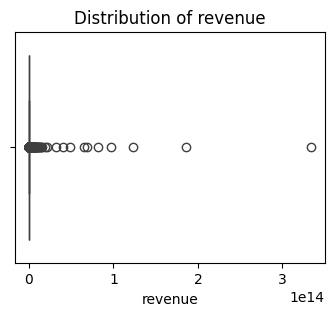

In [163]:
#distribution of revenue
plt.figure(figsize=(4,3))
sns.boxplot(x=df['revenue'])
plt.title('Distribution of revenue')
plt.show()

                           employees  employees_year  revenue  revenue_year  \
employees                       1.00            0.06     0.07          0.06   
employees_year                  0.06            1.00     0.01          0.44   
revenue                         0.07            0.01     1.00          0.01   
revenue_year                    0.06            0.44     0.01          1.00   
net_income                      0.07            0.01     0.92          0.01   
net_income_year                 0.06            0.42     0.01          0.96   
market_cap                      0.06            0.00     0.80          0.00   
legal_units_count               0.20            0.03    -0.01          0.01   
direct_subsidiaries_count       0.16            0.02    -0.02         -0.00   
max_hierarchy_depth             0.16            0.04     0.02          0.03   

                           net_income  net_income_year  market_cap  \
employees                        0.07             0.06      

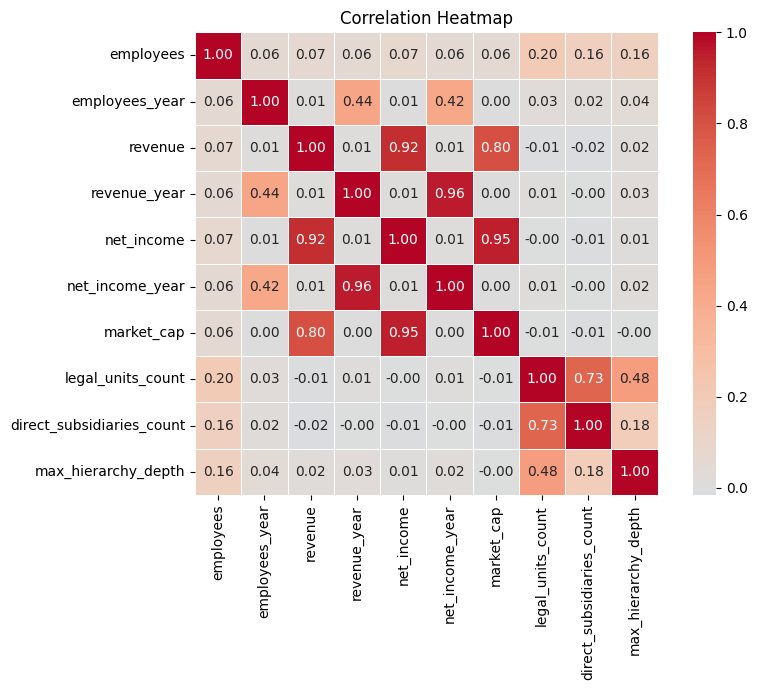

In [164]:
numeric_cols=df.select_dtypes(include='number').columns
corr= df[numeric_cols].corr()
print(corr.round(2))
plt.figure(figsize=(9,7))
sns.heatmap(corr,annot=True,fmt='.2f' ,cmap='coolwarm',center=0,
            square=True,linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

analytical answers
2.net_income and market cap are the two fields which have a strong relationship with revenue
3.the effect of net_income and market cap can strongly influence the revenue f the firms

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1755 entries, 0 to 1754
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   enterprise_group_id             1755 non-null   object 
 1   display_name                    1755 non-null   object 
 2   enterprise_group_name           1755 non-null   object 
 3   group_root_lei                  1755 non-null   object 
 4   enterprise_group_jurisdiction   1755 non-null   object 
 5   enterprise_group_entity_status  1755 non-null   object 
 6   website                         1716 non-null   object 
 7   company_type                    1753 non-null   object 
 8   employees                       1656 non-null   float64
 9   employees_year                  1655 non-null   float64
 10  revenue                         1654 non-null   float64
 11  revenue_currency                1654 non-null   object 
 12  revenue_year                    16

In [166]:
df.isnull().sum()

,0
enterprise_group_id,0
display_name,0
enterprise_group_name,0
group_root_lei,0
enterprise_group_jurisdiction,0
enterprise_group_entity_status,0
website,39
company_type,2
employees,99
employees_year,100


Task 2

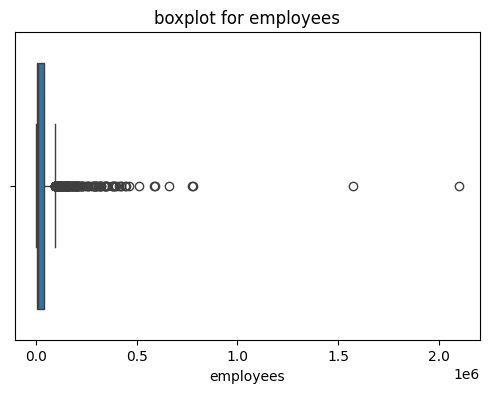

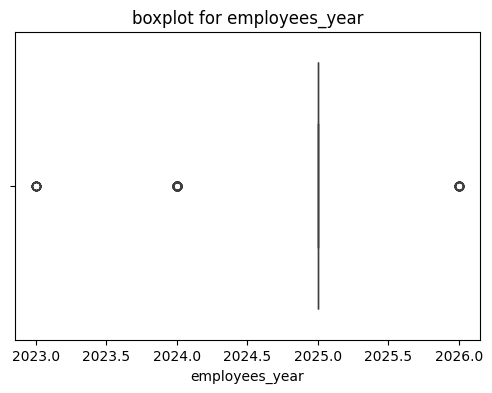

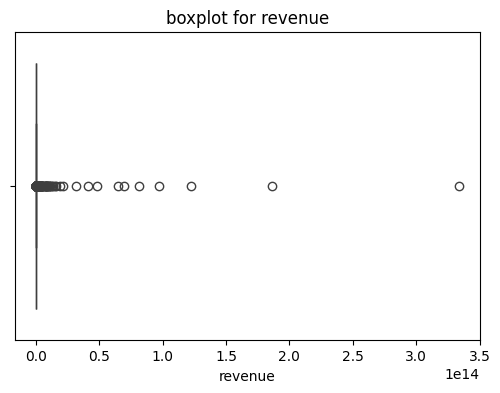

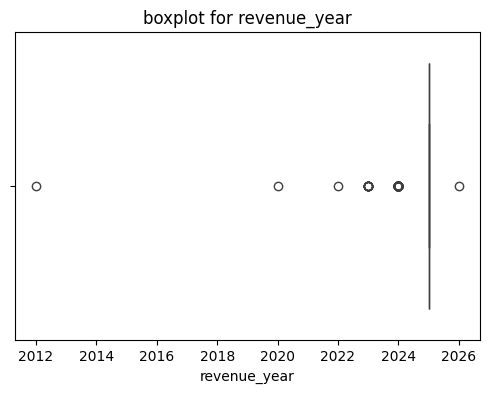

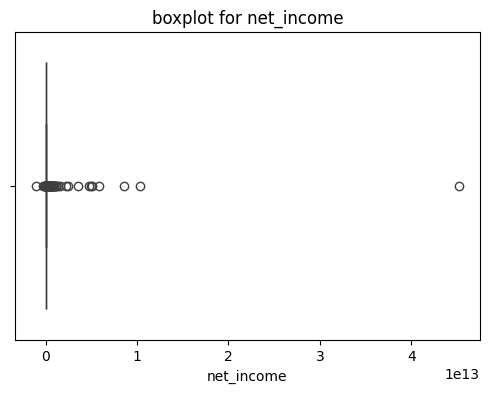

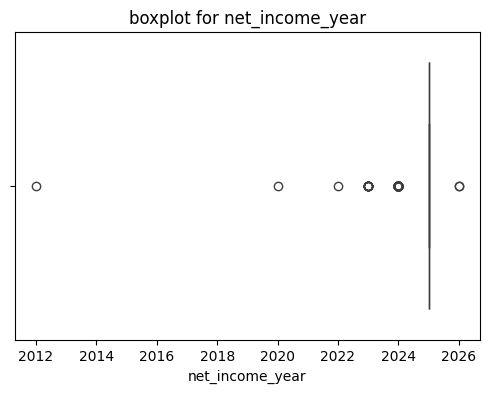

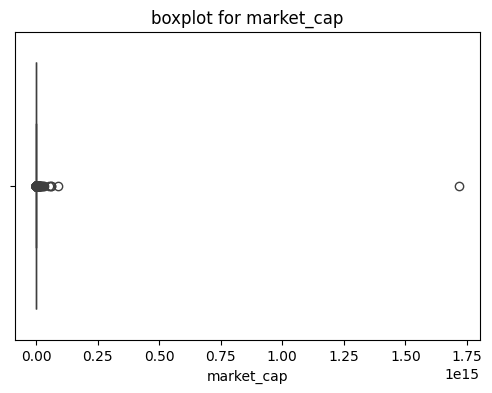

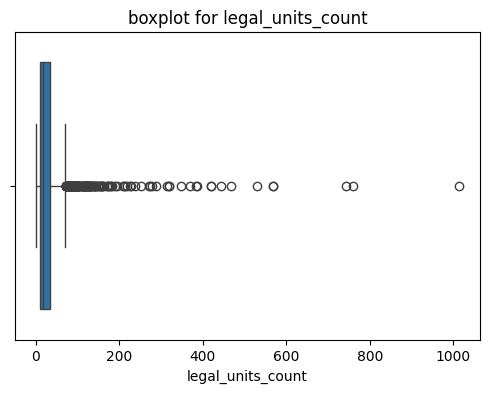

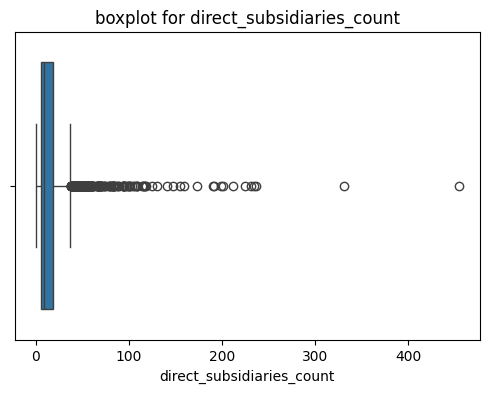

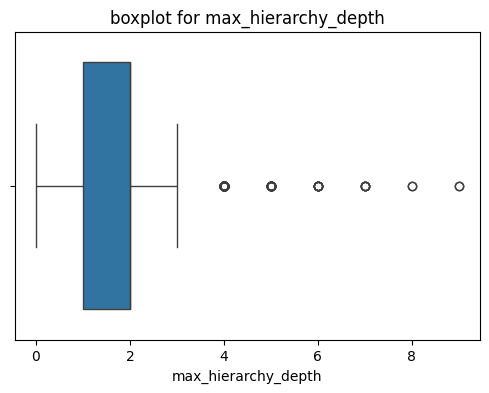

In [167]:
#2.1 to handle missing values
df=df.drop_duplicates().reset_index(drop=True)
df['market_cap_date']=pd.to_datetime(df['market_cap_date'],format='mixed',dayfirst=False,errors='coerce')
for col in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])
  plt.title(f'boxplot for {col}')
  plt.show()



In [168]:
#missing value filling
df['website']=df['website'].fillna(df['website'].mode()[0])
df['company_type']=df['company_type'].fillna(df['company_type'].mode()[0])
df['employees']=df['employees'].fillna(df['employees'].median())
df['employees_year']=df['employees_year'].fillna(df['employees_year'].median())
df['revenue']=df['revenue'].fillna(df['revenue'].median())
df['revenue_currency']=df['revenue_currency'].fillna(df['revenue_currency'].mode()[0])
df['revenue_year']=df['revenue_year'].fillna(df['revenue_year'].median())
df['net_income_currency']=df['net_income_currency'].fillna(df['net_income_currency'].mode()[0])
df['net_income_year']=df['net_income_year'].fillna(df['net_income_year'].median())
df['market_cap']=df['market_cap'].fillna(df['market_cap'].median())
df['market_cap_date'] = df['market_cap_date'].ffill()
df['direct_subsidiaries_count']=df['direct_subsidiaries_count'].fillna(df['direct_subsidiaries_count'].median())
df['max_hierarchy_depth']=df['max_hierarchy_depth'].fillna(df['max_hierarchy_depth'].median())
df['website_source']=df['website_source'].fillna(df['website_source'].mode()[0])
df['employees_source']=df['employees_source'].fillna(df['employees_source'].mode()[0])
df['revenue_source']=df['revenue_source'].fillna(df['revenue_source'].mode()[0])
df['net_income_source']=df['net_income_source'].fillna(df['net_income_source'].mode()[0])
df['market_cap_source']=df['market_cap_source'].fillna(df['market_cap_source'].mode()[0])
df['net_income']=df['net_income'].fillna(df['net_income'].median())
df['market_cap_currency']=df['market_cap_currency'].fillna(df['market_cap_currency'].mode()[0])

df.isnull().sum()

,0
enterprise_group_id,0
display_name,0
enterprise_group_name,0
group_root_lei,0
enterprise_group_jurisdiction,0
enterprise_group_entity_status,0
website,0
company_type,0
employees,0
employees_year,0


In [169]:
#2.3 selecting the relevant feature
target = "revenue"
df[target] = pd.to_numeric(df[target], errors="coerce")
data = df.dropna(subset=[target])

categorical_cols = data.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = data.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target]

for col in categorical_cols:
    temp = data[[col, target]].dropna()
    groups = [
        group[target].values
        for _, group in temp.groupby(col)
        if len(group) >= 2
    ]
    if len(groups) >= 2:
        statistic, p_value = f_oneway(*groups)
        verdict = "significant" if p_value < 0.05 else "not significant"
        print(f'{col} -> p-value: {p_value:.4f} ')
        print(f'-> verdict: {verdict}')

for col in numeric_cols:
    temp = data[[col, target]].dropna()
    if len(temp) >= 3:
        correlation, p_value = spearmanr(temp[col], temp[target])
        verdict = "significant" if p_value < 0.05 else "not significant"
        print(f'{col} -> Spearman correl: {correlation:.4f}')
        print(f'p-value: {p_value:.4f} -> verdict: {verdict}')


display_name -> p-value: 0.4459 
-> verdict: not significant
enterprise_group_jurisdiction -> p-value: 0.0000 
-> verdict: significant
website -> p-value: 0.0000 
-> verdict: significant
company_type -> p-value: 0.5777 
-> verdict: not significant
revenue_currency -> p-value: 0.0000 
-> verdict: significant
net_income_currency -> p-value: 0.0000 
-> verdict: significant
market_cap_currency -> p-value: 0.0000 
-> verdict: significant
website_source -> p-value: 0.1099 
-> verdict: not significant
employees_source -> p-value: 1.0000 
-> verdict: not significant
revenue_source -> p-value: 0.5867 
-> verdict: not significant
net_income_source -> p-value: 0.9976 
-> verdict: not significant
market_cap_source -> p-value: 0.0000 
-> verdict: significant
employees -> Spearman correl: 0.6986
p-value: 0.0000 -> verdict: significant
employees_year -> Spearman correl: 0.1490
p-value: 0.0000 -> verdict: significant
revenue_year -> Spearman correl: 0.2598
p-value: 0.0000 -> verdict: significant
net_i

In [170]:
#rrelevant fetured datset
df_cleaned=df.copy()
df_cleaned=df_cleaned.dropna(subset=['revenue'])
categorical_cols = [
    "enterprise_group_jurisdiction","website","revenue_currency","net_income_currency",
    "market_cap_currency","market_cap_source"
]
numeric_cols = [
    "employees","employees_year","revenue_year","net_income","net_income_year",
    "market_cap","legal_units_count","direct_subsidiaries_count","max_hierarchy_depth"
]
significant_features = categorical_cols +numeric_cols
df_cleaned = df_cleaned[significant_features + ["revenue"]]

In [171]:
#iqr method
num_col = df_cleaned.select_dtypes(include="number").columns
for col in num_col:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[
        (df_cleaned[col] >= lower) &
        (df_cleaned[col] <= upper) ]

df_cleaned = df_cleaned.reset_index(drop=True)

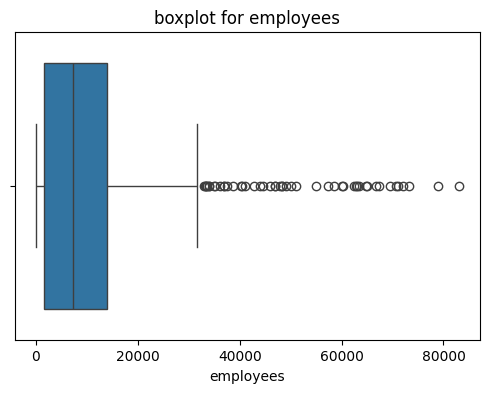

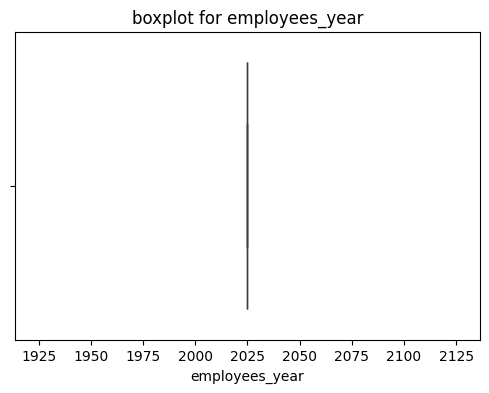

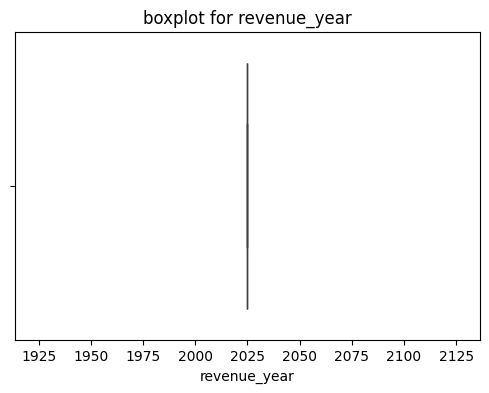

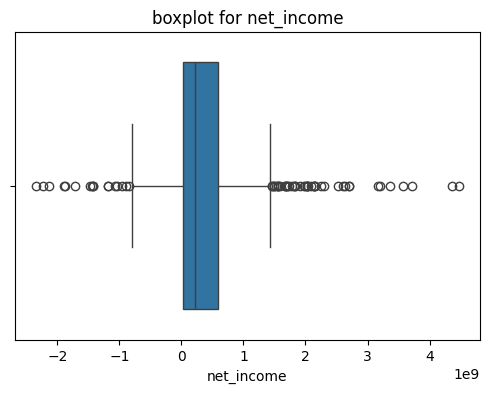

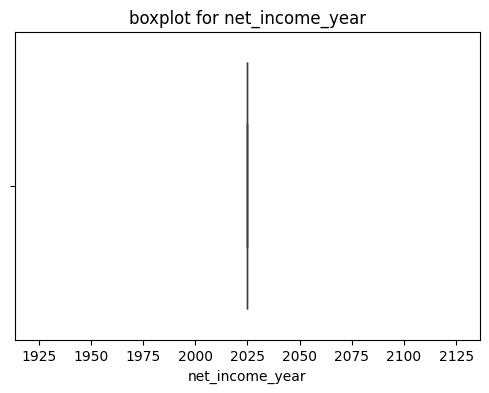

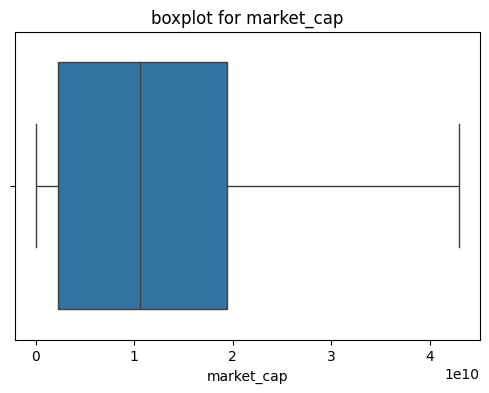

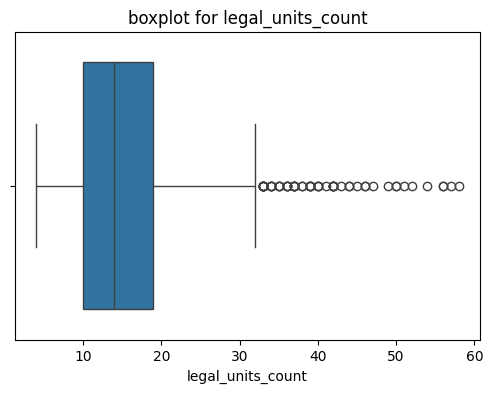

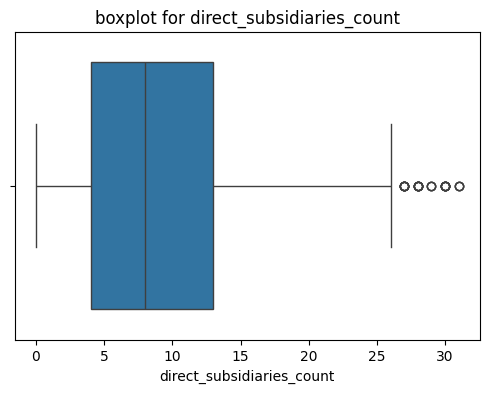

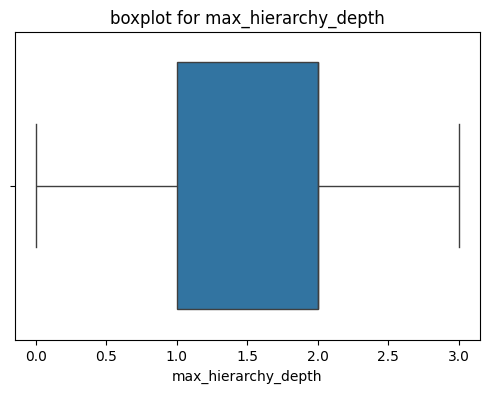

In [172]:
for col in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df_cleaned[col])
  plt.title(f'boxplot for {col}')
  plt.show()

In [173]:
df_cleaned.shape

(758, 16)

In [174]:
df_cleaned.isnull().sum()

,0
enterprise_group_jurisdiction,0
website,0
revenue_currency,0
net_income_currency,0
market_cap_currency,0
market_cap_source,0
employees,0
employees_year,0
revenue_year,0
net_income,0


In [175]:
#2.2 encoded categoricalvariables
categorical_cols=df_cleaned.select_dtypes(include='object').columns
df_cleaned=pd.get_dummies(df_cleaned,columns=categorical_cols,drop_first=True,dtype=int)

In [176]:
#2.4prepared the datset for modelling
X=df_cleaned.drop(columns=['revenue'])
y=df_cleaned['revenue']
joblib.dump(X.columns.tolist(),'encoder.pkl')
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)



In [177]:
#scaling
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train[numeric_cols])
X_test=scaler.transform(X_test[numeric_cols])
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

Analytical answer
1.we have done filling missing values using the imputation methods like median and mode and also applied iqr methods to handle outliers in the numeric fields
2.categorical variable need to be encode because the machine only takes input as numerical values rather than the categorical values

Task 3


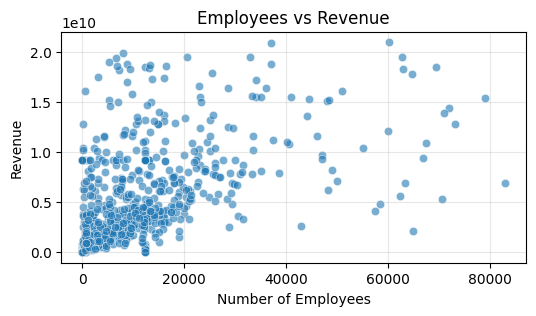

In [178]:
#employees vs revenue
plot_data=df_cleaned[['employees', 'revenue']].dropna()
plt.figure(figsize=(6, 3))
sns.scatterplot(
    data=plot_data,
    x='employees',
    y='revenue',
    alpha=0.6
)
plt.title('Employees vs Revenue')
plt.xlabel('Number of Employees')
plt.ylabel('Revenue')
plt.grid(True, alpha=0.3)
plt.show()

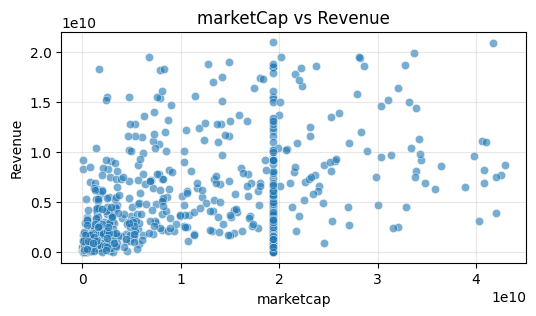

In [179]:
#market capitalization vs revenue
plot_data=df_cleaned[['market_cap', 'revenue']].dropna()
plt.figure(figsize=(6, 3))
sns.scatterplot(
    data=plot_data,
    x='market_cap',
    y='revenue',
    alpha=0.6
)
plt.title('marketCap vs Revenue')
plt.xlabel('marketcap')
plt.ylabel('Revenue')
plt.grid(True, alpha=0.3)
plt.show()

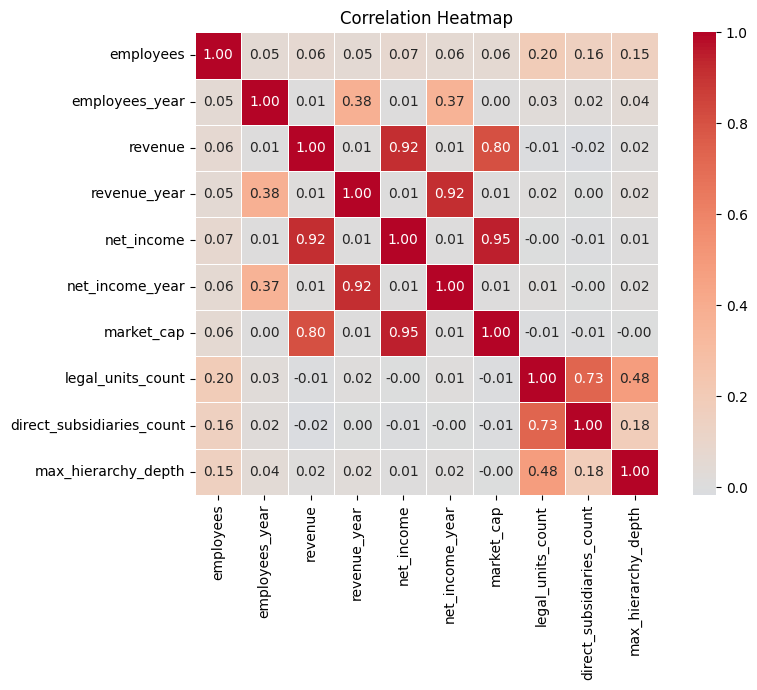

In [180]:
ncols = df.select_dtypes(include="number").columns
corr = df[ncols].corr()
plt.figure(figsize=(9, 7))

sns.heatmap(corr,annot=True,fmt='.2f' ,cmap='coolwarm',center=0,
            square=True,linewidths=0.5)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

analytical answers
1.majority of employeess are under 2500 of revenue 1.0e
2.looking at the graph we can see that the market cap is spread as the revenue increases and also at the begining of the graph there is a concentrated amount of scatters
3.net income appeaers to be the strongest predictors of revenue since it has high correlation

task 4

In [181]:
#4.1 train and compare the models
lr_model=LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred=lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test,lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test,lr_pred))
lr_r2 = r2_score(y_test,lr_pred)
joblib.dump(lr_model, "linear_regression_revenue_model.joblib")
print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression
MAE: 2738045283.2779255
RMSE: 3601013737.347695
R2 Score: 0.39372928589376655


In [182]:
d_model=DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

d_model.fit(X_train, y_train)
d_pred= d_model.predict(X_test)

d_mae = mean_absolute_error(y_test,d_pred)
d_rmse = np.sqrt(
    mean_squared_error(y_test,d_pred)
)
d_r2 = r2_score(y_test,d_pred)

print("Decision Tree Regression")
print("MAE:",d_mae)
print("RMSE:",d_rmse)
print("R2 Score:",d_r2)

Decision Tree Regression
MAE: 3090583375.307043
RMSE: 4430448837.797957
R2 Score: 0.08227516320938255


In [183]:
f_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
f_model.fit(X_train, y_train)
f_pred = f_model.predict(X_test)
f_mae = mean_absolute_error(y_test, f_pred)
f_rmse = np.sqrt(
    mean_squared_error(y_test, f_pred)
)
f_r2 = r2_score(y_test, f_pred)
print("Random Forest Regression")
print("MAE:", f_mae)
print("RMSE:", f_rmse)
print("R2 Score:", f_r2)

Random Forest Regression
MAE: 2776046233.6493173
RMSE: 3859527884.652333
R2 Score: 0.30355728502810897


In [184]:
g_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
g_model.fit(X_train, y_train)
g_pred = g_model.predict(X_test)
g_mae = mean_absolute_error(y_test, g_pred)
g_rmse = np.sqrt(
    mean_squared_error(y_test, g_pred)
)
g_r2 = r2_score(y_test, g_pred)

print("Gradient Boosting Regression")
print("MAE:", g_mae)
print("RMSE:", g_rmse)
print("R2 Score:", g_r2)

Gradient Boosting Regression
MAE: 2675568129.8410344
RMSE: 3670279134.5401645
R2 Score: 0.37018177533742347


analytical answers
1.logistic regression performed best with r2 score of 0.39 compared to other model
2.mean absolute error is preferred